# Reporte 06: Clasificación Garibelt — Tablero de Diagnóstico Topológico VFT

## Descripción

La **Clasificación Garibelt** es el tablero de diagnóstico de la red de transporte de la ZMVM dentro del VFT Model. Compila los 5 indicadores topológicos disponibles (Fases 1–3) y clasifica el desempeño de la red en cada dimensión según la **Escala Garibelt**.

La Clasificación Garibelt **no agrega** los indicadores a un único escalar global. Su propósito es diagnosticar fortalezas, debilidades y puntos críticos estructurales por dimensión, preservando la heterogeneidad entre ellas.

### Escala Garibelt — 4 bandas

| Banda | Rango normalizado | Interpretación urbana |
|-------|-------------------|-----------------------|
| 🔴 Crítico   | [0.00, 0.25) | Deficiencia estructural severa. Intervención prioritaria. |
| 🟠 Débil     | [0.25, 0.50) | Rendimiento por debajo de la mediana de la red. Área de mejora. |
| 🔵 Aceptable | [0.50, 0.75) | Desempeño adecuado para la función urbana. |
| 🟢 Idóneo    | [0.75, 1.00] | La red es estructuralmente apta en esta dimensión. |

### Dimensiones compiladas (v1)

| # | Dimensión | Indicador | Símbolo | Fase |
|---|-----------|-----------|---------|------|
| 1 | Accesibilidad | Cobertura Espacial | $C$ | 1 |
| 2 | Conectividad capilar | Alimentación Capilar | $C_i$ | 1 |
| 3 | Eficiencia de ruta | Índice de Ruta Directa | $DI$ | 1 |
| 4 | Fluidez global | Tiempo de Viaje Promedio | $T$ | 3 |
| 5 | Centralidad crítica | Centralidad de Intermediación | $B(v)$ | 3 |

### Indicadores excluidos (Clasificación Garibelt v1)

| Indicador | Razón |
|-----------|-------|
| $W_{s,h}$ — Penalización Transferencia | Implementación parcial (v2) |
| $\Delta E$ — Robustez Geométrica | Fuera de alcance Fase 4 (Issue #5) |

---

**Requisito de ejecución:** Apimetro activo en `http://localhost:8080`. No se requiere servidor VFTModel — el notebook computa directamente desde `src/`.

In [18]:
# ============================================================
# Configuración de entorno
# ============================================================
import sys
import os
import ast
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

# Algoritmos VFT
from src.infrastructure.go_client.client import fetch_full_network
from src.infrastructure.go_client.client_spatial import fetch_territorial_polygons
from src.api.schemas.schemas import GeoJSONTransportSchema
from src.core.services.graph_builder import VFTGraphBuilder
from src.core.algorithms.topological.scc_analysis import SCCOrchestrator
from src.core.algorithms.topological.average_travel_time import AverageTravelTimeOrchestrator
from src.core.algorithms.topological.betweenness_centrality import BetweennessOrchestrator
from src.core.algorithms.topological.capillar_strength import CapillaryStrengthAnalyzer
from src.core.algorithms.topological.detaurFactor import DetourFactorOrchestrator
from src.core.algorithms.spatial.spatial_coverage import SpatialCoverageAnalyzer

# Clasificación Garibelt
from src.core.algorithms.composite.network_profile import (
    NetworkProfiler,
    T_REFERENCIA_MIN, T_WORST_CASE_MIN, DI_BEST, DI_WORST, COVERAGE_BEST
)
from src.core.algorithms.composite.normalization import (
    normalize_scalar, gini_coefficient, classify_band
)

# Paleta Escala Garibelt
GARIBELT_COLORS = {
    'critico':  '#e74c3c',
    'debil':    '#e67e22',
    'aceptable':'#3498db',
    'idoneo':   '#2ecc71',
}

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [19]:
# ============================================================
# §0  Construcción del grafo VFT
# ============================================================
print('Descargando red de transporte...')
raw_data = await fetch_full_network()
geojson_transporte = raw_data   # guardamos para cobertura más adelante

print('Construyendo grafo (REALISTIC_INTEGRATION, tolerance_m=85)...')
validated_payload = GeoJSONTransportSchema(**raw_data)
builder = VFTGraphBuilder(validated_payload)
G = builder.build_graph('REALISTIC_INTEGRATION', 85.0)

print(f'Grafo listo: {G.number_of_nodes():,} nodos | {G.number_of_edges():,} aristas')

Descargando red de transporte...
2026-09-18 20:01:33 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-09-18 20:01:33 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-09-18 20:01:33 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-09-18 20:01:34 | INFO     | VFT_Model | Red extraída: 23540 entidades espaciales listas para VFT.
Construyendo grafo (REALISTIC_INTEGRATION, tolerance_m=85)...
2026-09-18 20:01:34 | INFO     | VFT_Model | Iniciando VFTGraphBuilder en modo: REALISTIC_INTEGRATION
2026-09-18 20:01:34 | INFO     | VFT_Model | Fase 1 y 2: Extrayendo nodos y trazos base...
2026-09-18 20:01:36 | INFO     | VFT_Model | Fase 2 completada: 64467 aristas interestación creadas.
2026-09-18 20:01:36 | INFO     | VFT_Model | Grafo Base construido: 11115 Nodos y 32109 Segmentos.
2026-09-18 20:01:36 | WARNING  | VFT_Model | Eliminada

In [20]:
# ============================================================
# §0  Componente gigante (SCC)
# ============================================================
scc = SCCOrchestrator(G)
scc_report = scc.analyze()
G_giant = scc.get_giant_component()

giant_pct = scc_report['giant_component']['pct_of_total_nodes']
print(f"Componente gigante: {scc_report['giant_component']['nodes']:,} nodos ({giant_pct:.1f}%)")
print(f"Apta para Fases 3-4: {scc_report['phase_3_ready']}")

2026-09-18 20:01:58 | INFO     | VFT_Model | SCC: 209 componentes | Gigante: 10,561 nodos (95.0%) | APTA para Fase 3
Componente gigante: 10,561 nodos (95.0%)
Apta para Fases 3-4: True


---

## §1  Cómputo de indicadores

Ejecutamos cada indicador en el orden de dependencia de fases.
$T$ y $B(v)$ son los más lentos (~2-5 min y ~8-10 min respectivamente en primera ejecución).

In [21]:
# §1a — Fuerza Capilar (Cᵢ)  — rápido
t0 = time.time()
cap_analyzer = CapillaryStrengthAnalyzer(G)
capillar_df = cap_analyzer.calculate_capillary_strength(snap_tolerance_m=25.0)
print(f'Capilar: {len(capillar_df):,} nodos | {time.time()-t0:.1f}s')

Capilar: 11,115 nodos | 0.2s


In [22]:
# §1b — Detour Factor (DI)  — moderado (~30-60 s)
t0 = time.time()
detour_orch = DetourFactorOrchestrator(G)
detour_df = detour_orch.calculate_sample_routes(sample_size=500, seed=42)
print(f'Detour Factor: {len(detour_df):,} rutas O-D | {time.time()-t0:.1f}s')

Detour Factor: 500 rutas O-D | 9.0s


In [23]:
# §1c — Tiempo Promedio de Viaje (T)  — lento (~2-5 min)
print('Calculando T (all-pairs shortest paths)... puede tardar varios minutos')
t0 = time.time()
t_orch = AverageTravelTimeOrchestrator(G_giant)
t_report = t_orch.analyze()
travel_time_min = t_report['T_average_travel_time_minutes']
print(f'T = {travel_time_min:.2f} min | {time.time()-t0:.1f}s')

Calculando T (all-pairs shortest paths)... puede tardar varios minutos
2026-09-18 20:02:08 | INFO     | VFT_Model | Calculando T (Tiempo Promedio) sobre 10,561 nodos... Esto puede tardar varios minutos.
2026-09-18 20:06:00 | INFO     | VFT_Model | T (Tiempo Promedio de Viaje): 108.92 minutos
T = 108.92 min | 232.7s


In [24]:
# §1d — Centralidad de Intermediación B(v)  — lento (~8-10 min)
print('Calculando B(v) (Brandes)... puede tardar varios minutos')
t0 = time.time()
b_orch = BetweennessOrchestrator(G_giant)
b_report = b_orch.analyze()
betweenness_df = b_report['ranking']
print(f'B(v): {len(betweenness_df):,} nodos rankeados | {time.time()-t0:.1f}s')
print(f"Top 1: {b_report['summary']['top_5'][0]['nombre']} "
      f"(B={b_report['summary']['top_5'][0]['betweenness_centrality']:.4f})")

Calculando B(v) (Brandes)... puede tardar varios minutos
2026-09-18 20:06:00 | INFO     | VFT_Model | Calculando B (Betweenness Centrality) sobre 10,561 nodos...
2026-09-18 20:14:52 | INFO     | VFT_Model | B (Betweenness): Top nodo = Tacubaya (B=0.2179)
B(v): 10,561 nodos rankeados | 531.9s
Top 1: Tacubaya (B=0.2179)


In [25]:
# §1e — Cobertura Espacial (C)  — requiere polígonos territoriales
# Degradación graceful: si los polígonos no están disponibles, coverage_df = None
coverage_df = None
try:
    geojson_poligono = await fetch_territorial_polygons(
        entidades=['Ciudad de México', 'Estado de México']
    )
    cov_analyzer = SpatialCoverageAnalyzer(geojson_transporte, geojson_poligono)
    coverage_df = cov_analyzer.calculate_general_coverage(radio_caminable_m=800.0)
    print(f'Cobertura: {len(coverage_df)} demarcaciones calculadas')
except Exception as e:
    print(f'Cobertura no disponible: {e}')
    print('La dimensión accesibilidad se marcará como "no_disponible" en el PRE')

2026-09-18 20:14:52 | INFO     | VFT_Model | Solicitando polígonos territoriales a APIMETRO para: ['Ciudad de México', 'Estado de México']
2026-09-18 20:14:52 | INFO     | VFT_Model | Polígonos combinados exitosamente. Total features: 141
Cobertura: 141 demarcaciones calculadas


---

## §2  Estadística descriptiva por dimensión

Análisis de la distribución de cada indicador antes de la normalización.
Estos valores son la base para calibrar los umbrales empíricos del PRE.

=== Fuerza Capilar (Cᵢ) — Grado nodal ===


,n_nodos,media,mediana,std,min,Q1 (25%),Q2 (50%),Q3 (75%),max,Gini
0,11115,8.1866,7.0000,4.2561,0,6.0000,7.0000,10.0000,41,0.2791


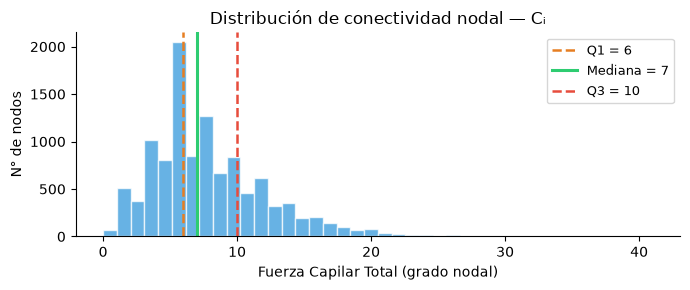


Interpretación Gini=0.2791:
  0 = conectividad perfectamente equitativa entre nodos
  1 = toda la conectividad concentrada en un solo nodo
  Red ZMVM: concentración moderada


In [26]:
# §2a — Distribución de Fuerza Capilar (Cᵢ)
print('=== Fuerza Capilar (Cᵢ) — Grado nodal ===')
fc = capillar_df['Fuerza_Capilar_Total']
q1_fc = fc.quantile(0.25)
med_fc = fc.median()
q3_fc = fc.quantile(0.75)

stats_cap = pd.DataFrame({
    'n_nodos':   [len(fc)],
    'media':     [fc.mean()],
    'mediana':   [med_fc],
    'std':       [fc.std()],
    'min':       [fc.min()],
    'Q1 (25%)':  [q1_fc],
    'Q2 (50%)':  [med_fc],
    'Q3 (75%)':  [q3_fc],
    'max':       [fc.max()],
    'Gini':      [round(gini_coefficient(fc.tolist()), 4)]
})
display(stats_cap)

# Gráfica: histograma con percentiles
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(fc, bins=40, color=GARIBELT_COLORS['aceptable'], alpha=0.75, edgecolor='white')
ax.axvline(q1_fc,  color=GARIBELT_COLORS['debil'],    linestyle='--', linewidth=1.8,
           label=f'Q1 = {q1_fc:.0f}')
ax.axvline(med_fc, color=GARIBELT_COLORS['idoneo'],   linestyle='-',  linewidth=2.2,
           label=f'Mediana = {med_fc:.0f}')
ax.axvline(q3_fc,  color=GARIBELT_COLORS['critico'],  linestyle='--', linewidth=1.8,
           label=f'Q3 = {q3_fc:.0f}')
ax.set_xlabel('Fuerza Capilar Total (grado nodal)')
ax.set_ylabel('N° de nodos')
ax.set_title('Distribución de conectividad nodal — Cᵢ')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nInterpretación Gini={stats_cap["Gini"].iloc[0]:.4f}:')
print('  0 = conectividad perfectamente equitativa entre nodos')
print('  1 = toda la conectividad concentrada en un solo nodo')
print(f'  Red ZMVM: {"alta concentración" if stats_cap["Gini"].iloc[0] > 0.5 else "concentración moderada"}')

=== Índice de Ruta Directa (DI) — Factor de Desviación ===


,n_rutas,media,mediana,std,min,Q1 (25%),Q3 (75%),max,pct_idóneo (<=1.3),pct_crítico (>2.0)
0,500,1.5395,1.4300,0.4562,0.8600,1.2600,1.6900,5.1600,32.4000,10.4000


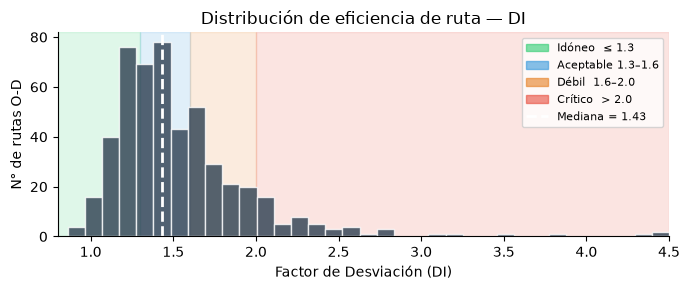


Referencia de categorías DI:


,Banda Garibelt,Umbral,Interpretación
0,Idóneo,DI ≤ 1.3,Ruta casi directa
1,Aceptable,1.3 < DI ≤ 1.6,Desvío tolerable
2,Débil,1.6 < DI ≤ 2.0,Desvío significativo
3,Crítico,DI > 2.0,Ineficiencia estructural


In [27]:
# §2b — Distribución de Detour Factor (DI)
print('=== Índice de Ruta Directa (DI) — Factor de Desviación ===')
di = detour_df['Factor_Desviacion']

stats_di = pd.DataFrame({
    'n_rutas':              [len(di)],
    'media':                [di.mean()],
    'mediana':              [di.median()],
    'std':                  [di.std()],
    'min':                  [di.min()],
    'Q1 (25%)':             [di.quantile(0.25)],
    'Q3 (75%)':             [di.quantile(0.75)],
    'max':                  [di.max()],
    'pct_idóneo (<=1.3)':   [round((di <= 1.3).mean() * 100, 1)],
    'pct_crítico (>2.0)':   [round((di > 2.0).mean() * 100, 1)]
})
display(stats_di)

# Gráfica: histograma con zonas de categoría Garibelt
xmax = min(float(di.max()) + 0.2, 4.5)
fig, ax = plt.subplots(figsize=(7, 3))
ax.axvspan(0.8,  1.3,  alpha=0.15, color=GARIBELT_COLORS['idoneo'])
ax.axvspan(1.3,  1.6,  alpha=0.15, color=GARIBELT_COLORS['aceptable'])
ax.axvspan(1.6,  2.0,  alpha=0.15, color=GARIBELT_COLORS['debil'])
ax.axvspan(2.0,  xmax, alpha=0.15, color=GARIBELT_COLORS['critico'])
ax.hist(di.clip(upper=xmax), bins=35, color='#2c3e50', alpha=0.8, edgecolor='white')
med_line = ax.axvline(di.median(), color='white', linestyle='--', linewidth=2)
patches = [
    mpatches.Patch(color=GARIBELT_COLORS['idoneo'],    alpha=0.6, label='Idóneo  ≤ 1.3'),
    mpatches.Patch(color=GARIBELT_COLORS['aceptable'], alpha=0.6, label='Aceptable 1.3–1.6'),
    mpatches.Patch(color=GARIBELT_COLORS['debil'],     alpha=0.6, label='Débil  1.6–2.0'),
    mpatches.Patch(color=GARIBELT_COLORS['critico'],   alpha=0.6, label='Crítico  > 2.0'),
]
ax.legend(handles=patches + [med_line],
          labels=[p.get_label() for p in patches] + [f'Mediana = {di.median():.2f}'],
          fontsize=8, loc='upper right')
ax.set_xlabel('Factor de Desviación (DI)')
ax.set_ylabel('N° de rutas O-D')
ax.set_title('Distribución de eficiencia de ruta — DI')
ax.set_xlim(0.8, xmax)
plt.tight_layout()
plt.show()

print('\nReferencia de categorías DI:')
cat_table = pd.DataFrame([
    {'Banda Garibelt': 'Idóneo',    'Umbral': 'DI ≤ 1.3',       'Interpretación': 'Ruta casi directa'},
    {'Banda Garibelt': 'Aceptable', 'Umbral': '1.3 < DI ≤ 1.6', 'Interpretación': 'Desvío tolerable'},
    {'Banda Garibelt': 'Débil',     'Umbral': '1.6 < DI ≤ 2.0', 'Interpretación': 'Desvío significativo'},
    {'Banda Garibelt': 'Crítico',   'Umbral': 'DI > 2.0',        'Interpretación': 'Ineficiencia estructural'},
])
display(cat_table)

=== Centralidad de Intermediación B(v) ===


,n_nodos,media,mediana,std,Q1 (25%),Q3 (75%),max,nodo_max,Gini_B
0,10561,0.0035,0.0007,0.0107,0.0002,0.0026,0.2179,Tacubaya,0.7891


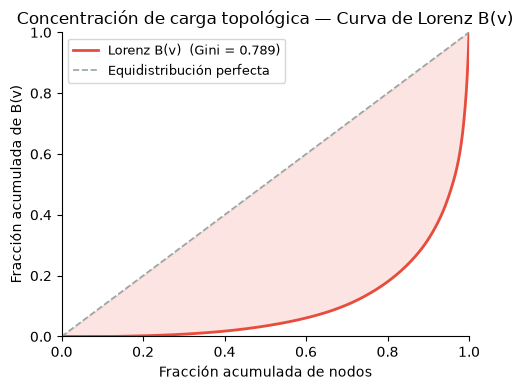


Top 10 nodos por B(v):


,nombre,sistema,alcaldia_municipio,es_cetram,betweenness_centrality
0,Tacubaya,METRO,Miguel Hidalgo,False,0.2179
1,Mixcoac,METRO,Benito Juárez,False,0.1725
2,Hidalgo,METRO,Cuauhtémoc,False,0.1595
3,Balderas,METRO,Cuauhtémoc,False,0.1433
4,Lázaro Cárdenas,METRO,Cuauhtémoc,False,0.1376
5,Chilpancingo,METRO,Cuauhtémoc,False,0.1366
6,Viaducto,METRO,Benito Juárez,False,0.1346
7,Villa de Cortés,METRO,Benito Juárez,False,0.1341
8,Nativitas,METRO,Benito Juárez,False,0.1299
9,Zapata,METRO,Benito Juárez,False,0.1283


In [28]:
# §2c — Distribución de Centralidad de Intermediación B(v)
print('=== Centralidad de Intermediación B(v) ===')
bv = betweenness_df['betweenness_centrality']
gini_bv = round(gini_coefficient(bv.tolist()), 4)

stats_b = pd.DataFrame({
    'n_nodos':  [len(bv)],
    'media':    [bv.mean()],
    'mediana':  [bv.median()],
    'std':      [bv.std()],
    'Q1 (25%)': [bv.quantile(0.25)],
    'Q3 (75%)': [bv.quantile(0.75)],
    'max':      [bv.max()],
    'nodo_max': [betweenness_df.iloc[0]['nombre']],
    'Gini_B':   [gini_bv]
})
display(stats_b)

# Gráfica: Curva de Lorenz — muestra la concentración que captura el Gini
sorted_b = np.sort(bv.values)
cum_b = np.cumsum(sorted_b) / sorted_b.sum()
n_b   = len(sorted_b)
cum_n = np.arange(1, n_b + 1) / n_b

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(np.r_[0, cum_n], np.r_[0, cum_b],
        color=GARIBELT_COLORS['critico'], linewidth=2,
        label=f'Lorenz B(v)  (Gini = {gini_bv:.3f})')
ax.plot([0, 1], [0, 1],
        color='#95a5a6', linestyle='--', linewidth=1.2,
        label='Equidistribución perfecta')
ax.fill_between(np.r_[0, cum_n], np.r_[0, cum_b], np.r_[0, cum_n],
                alpha=0.15, color=GARIBELT_COLORS['critico'])
ax.set_xlabel('Fracción acumulada de nodos')
ax.set_ylabel('Fracción acumulada de B(v)')
ax.set_title('Concentración de carga topológica — Curva de Lorenz B(v)')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('\nTop 10 nodos por B(v):')
cols_b = ['nombre', 'sistema', 'alcaldia_municipio', 'es_cetram', 'betweenness_centrality']
display(betweenness_df[cols_b].head(10))

=== Tiempo Promedio de Viaje (T) ===
T = 108.92 min  |  Referencia CDMX: 85.0 min  |  Peor caso: 180.0 min
Score normalizado: 0.748  →  Banda: ACEPTABLE


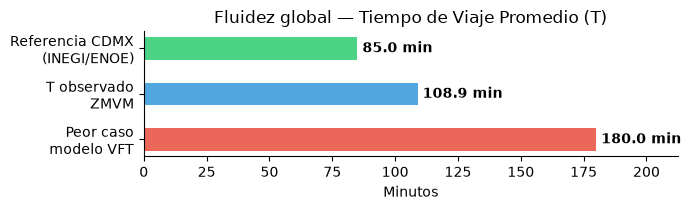


=== Cobertura Espacial (C) por demarcación ===


,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
18,Benito Juárez,26.6800,26.6800,100.0000
34,Cuauhtémoc,32.5000,32.5000,100.0000
50,Iztacalco,23.0800,23.0800,100.0000
67,Miguel Hidalgo,46.3900,46.2100,99.6200
17,Azcapotzalco,33.5000,33.3400,99.5200
...,...,...,...,...
132,Xalatlaco,110.4300,0.0000,0.0000
2,Aculco,464.5200,0.0000,0.0000
134,Xonacatlán,33.2500,0.0000,0.0000
135,Zacazonapan,66.6700,0.0000,0.0000



Cobertura global ponderada por área: 4.41%


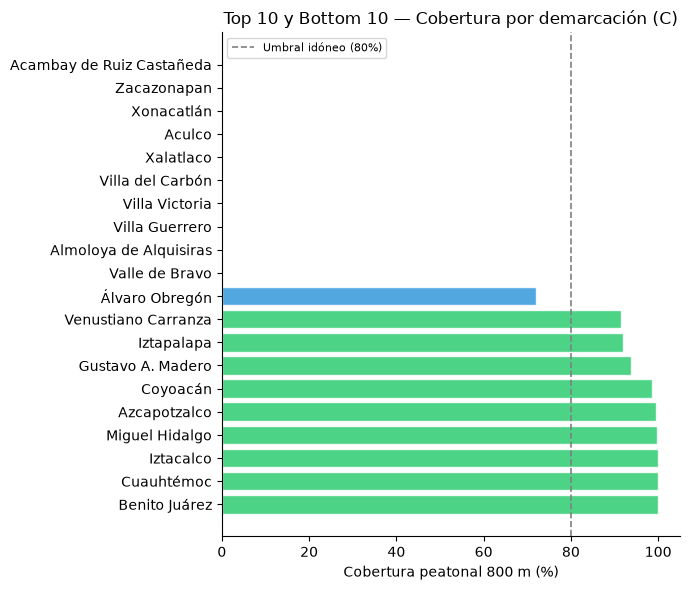

In [29]:
# §2d — T (Tiempo Promedio) y C (Cobertura)
print('=== Tiempo Promedio de Viaje (T) ===')
t_score = normalize_scalar(T_WORST_CASE_MIN - travel_time_min, 0.0, T_WORST_CASE_MIN - T_REFERENCIA_MIN)
print(f'T = {travel_time_min:.2f} min  |  Referencia CDMX: {T_REFERENCIA_MIN} min  |  Peor caso: {T_WORST_CASE_MIN} min')
print(f'Score normalizado: {t_score:.3f}  →  Banda: {classify_band(t_score).upper()}')

# Gráfica T: comparación de referencias
fig, ax = plt.subplots(figsize=(7, 2.2))
categorias = ['Referencia CDMX\n(INEGI/ENOE)', f'T observado\nZMVM', 'Peor caso\nmodelo VFT']
valores    = [T_REFERENCIA_MIN, travel_time_min, T_WORST_CASE_MIN]
colores_t  = [GARIBELT_COLORS['idoneo'], GARIBELT_COLORS['aceptable'], GARIBELT_COLORS['critico']]
bars = ax.barh(categorias, valores, color=colores_t, alpha=0.85, height=0.5)
for bar, val in zip(bars, valores):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} min', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Minutos')
ax.set_title('Fluidez global — Tiempo de Viaje Promedio (T)')
ax.set_xlim(0, T_WORST_CASE_MIN * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print()
if coverage_df is not None:
    print('=== Cobertura Espacial (C) por demarcación ===')
    cols_cov = ['Demarcacion', 'Area_Total_km2', 'Area_Cubierta_km2', 'Cobertura_Porcentaje']
    display(coverage_df[cols_cov].sort_values('Cobertura_Porcentaje', ascending=False))
    total = coverage_df['Area_Total_km2'].sum()
    cob_ponderada = (coverage_df['Cobertura_Porcentaje'] * coverage_df['Area_Total_km2']).sum() / total
    print(f'\nCobertura global ponderada por área: {cob_ponderada:.2f}%')

    # Gráfica cobertura: top-10 y bottom-10 demarcaciones
    df_sorted = coverage_df.sort_values('Cobertura_Porcentaje', ascending=False)
    df_viz = pd.concat([df_sorted.head(10), df_sorted.tail(10)]).drop_duplicates()
    colores_bar = [
        GARIBELT_COLORS['idoneo']    if v >= 75 else
        GARIBELT_COLORS['aceptable'] if v >= 50 else
        GARIBELT_COLORS['debil']     if v >= 25 else
        GARIBELT_COLORS['critico']
        for v in df_viz['Cobertura_Porcentaje']
    ]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(df_viz['Demarcacion'], df_viz['Cobertura_Porcentaje'],
            color=colores_bar, alpha=0.85, edgecolor='white')
    ax.axvline(80, color='gray', linestyle='--', linewidth=1.2, label='Umbral idóneo (80%)')
    ax.set_xlabel('Cobertura peatonal 800 m (%)')
    ax.set_title('Top 10 y Bottom 10 — Cobertura por demarcación (C)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('=== Cobertura Espacial (C) ===')
    print('No disponible — Go backend no alcanzable.')

---

## §3  Normalización y umbrales de referencia

Cada dimensión se normaliza a $[0, 1]$ con criterios distintos según la naturaleza del indicador.
La tabla siguiente documenta los umbrales usados y su justificación para asegurar reproducibilidad.

In [30]:
# §3 — Tabla de umbrales de normalización
q1_fc  = float(capillar_df['Fuerza_Capilar_Total'].quantile(0.25))
q3_fc  = float(capillar_df['Fuerza_Capilar_Total'].quantile(0.75))
med_fc = float(capillar_df['Fuerza_Capilar_Total'].median())
gini_bv = round(gini_coefficient(betweenness_df['betweenness_centrality'].tolist()), 4)
med_di  = float(detour_df['Factor_Desviacion'].median())

norm_table = pd.DataFrame([
    {
        'Dimensión': 'Accesibilidad (C)',
        'Tipo calibración': 'Literatura',
        'Fórmula': 'min-max(C, 0, 80%)',
        'Umbral bajo': '0%',
        'Umbral alto': '80%',
        'Justificación': 'Estándar accesibilidad peatonal urbana'
    },
    {
        'Dimensión': 'Capilar (Cᵢ)',
        'Tipo calibración': 'Empírico',
        'Fórmula': f'min-max(mediana, Q1={q1_fc:.0f}, Q3={q3_fc:.0f})',
        'Umbral bajo': f'Q1={q1_fc:.0f}',
        'Umbral alto': f'Q3={q3_fc:.0f}',
        'Justificación': f'Percentiles propios del dataset. Mediana={med_fc:.0f} como estadístico percentilar robusto a outliers'
    },
    {
        'Dimensión': 'Eficiencia (DI)',
        'Tipo calibración': 'Fijo (modelo)',
        'Fórmula': f'(DI_WORST - mediana) / (DI_WORST - DI_BEST)  →  ({DI_WORST}-mediana)/{DI_WORST-DI_BEST:.1f}',
        'Umbral bajo': f'DI={DI_WORST} (peor)',
        'Umbral alto': f'DI={DI_BEST:.1f} (óptimo)',
        'Justificación': f'DI=1.0 ruta perfecta, DI≥2.5 ineficiencia crítica. Mediana actual: {med_di:.3f}'
    },
    {
        'Dimensión': 'Fluidez (T)',
        'Tipo calibración': 'Referencia INEGI',
        'Fórmula': f'(T_WORST - T) / (T_WORST - T_REF)  →  ({T_WORST_CASE_MIN}-T)/{T_WORST_CASE_MIN-T_REFERENCIA_MIN:.0f}',
        'Umbral bajo': f'{T_WORST_CASE_MIN} min (peor)',
        'Umbral alto': f'{T_REFERENCIA_MIN} min (ref. CDMX)',
        'Justificación': f'Referencia: expected_cdmx_approx=85 min (API). T actual: {travel_time_min:.1f} min'
    },
    {
        'Dimensión': 'Centralidad crítica (B)',
        'Tipo calibración': 'Empírico (Gini)',
        'Fórmula': '1 - Gini(B)',
        'Umbral bajo': 'Gini=1 (máx concentración)',
        'Umbral alto': 'Gini=0 (equidistribuido)',
        'Justificación': f'Alta concentración = alta vulnerabilidad estructural. Gini_B={gini_bv}'
    },
])

display(norm_table.style.hide(axis='index').set_caption('Tabla de umbrales Clasificación Garibelt v1 — ZMVM 2026'))

Dimensión,Tipo calibración,Fórmula,Umbral bajo,Umbral alto,Justificación
Accesibilidad (C),Literatura,"min-max(C, 0, 80%)",0%,80%,Estándar accesibilidad peatonal urbana
Capilar (Cᵢ),Empírico,"min-max(mediana, Q1=6, Q3=10)",Q1=6,Q3=10,Percentiles propios del dataset. Mediana=7 como estadístico percentilar robusto a outliers
Eficiencia (DI),Fijo (modelo),(DI_WORST - mediana) / (DI_WORST - DI_BEST) → (2.5-mediana)/1.5,DI=2.5 (peor),DI=1.0 (óptimo),"DI=1.0 ruta perfecta, DI≥2.5 ineficiencia crítica. Mediana actual: 1.430"
Fluidez (T),Referencia INEGI,(T_WORST - T) / (T_WORST - T_REF) → (180.0-T)/95,180.0 min (peor),85.0 min (ref. CDMX),Referencia: expected_cdmx_approx=85 min (API). T actual: 108.9 min
Centralidad crítica (B),Empírico (Gini),1 - Gini(B),Gini=1 (máx concentración),Gini=0 (equidistribuido),Alta concentración = alta vulnerabilidad estructural. Gini_B=0.7891


---

## §4  Clasificación Garibelt — ZMVM

Resultado del compilador topológico. Cada fila es una dimensión de la red clasificada en la Escala Garibelt.

In [31]:
# §4 — Construcción de la Clasificación Garibelt
profiler = NetworkProfiler(
    coverage_df=coverage_df,
    capillar_df=capillar_df,
    detour_df=detour_df,
    travel_time_min=travel_time_min,
    betweenness_df=betweenness_df,
)
result = profiler.build_profile()

# Serializar a DataFrame
df_garibelt = pd.DataFrame([
    {
        'Dimensión':  d.dimension,
        'Indicador':  d.indicador_fuente,
        'Valor bruto': d.valor_bruto,
        'Normalizado': d.valor_normalizado,
        'Banda':       d.banda,
        'Métrica':     d.metrica_descripcion,
    }
    for d in result.dimensions
])

# CSS Escala Garibelt
BAND_CSS = {
    'critico':       f'background-color: {GARIBELT_COLORS["critico"]};   color: white; font-weight: bold',
    'debil':         f'background-color: {GARIBELT_COLORS["debil"]};     color: white; font-weight: bold',
    'aceptable':     f'background-color: {GARIBELT_COLORS["aceptable"]}; color: white; font-weight: bold',
    'idoneo':        f'background-color: {GARIBELT_COLORS["idoneo"]};    color: white; font-weight: bold',
    'no_disponible': 'background-color: #95a5a6; color: white; font-style: italic',
}

def _color_banda(val):
    return BAND_CSS.get(val, '')

display(
    df_garibelt.style
        .map(_color_banda, subset=['Banda'])
        .format({'Normalizado': '{:.3f}', 'Valor bruto': '{:.4f}'})
        .set_caption('Clasificación Garibelt — ZMVM 2026 · VFT Model')
        .hide(axis='index')
)

Dimensión,Indicador,Valor bruto,Normalizado,Banda,Métrica
accesibilidad,C — Cobertura Espacial,4.4138,0.055,critico,Cobertura peatonal 800 m ponderada por área: 4.4%
conectividad_capilar,Cᵢ — Alimentación Capilar,7.0000,0.250,debil,Mediana grado nodal: 7.0 (escala Q1=6–Q3=10)
eficiencia_ruta,DI — Índice de Ruta Directa,1.4300,0.713,aceptable,Mediana Factor Desviación: 1.43 (1.0 = ruta directa perfecta)
fluidez_global,T — Tiempo de Viaje Promedio,108.9169,0.748,aceptable,T promedio shortest-path: 108.9 min (ref. CDMX: 85.0 min)
centralidad_critica,B(v) — Centralidad de Intermediación,0.7891,0.211,critico,"Gini de intermediación: 0.7891 (0 = distribuida, 1 = concentrada)"


In [32]:
# §4b — Distribución de bandas en el enriquecimiento por nodo
print(f'Nodos con enriquecimiento: {len(result.node_enrichment):,}')

# Conteo por banda dominante
band_counts = result.node_enrichment['banda_dominante'].value_counts().reset_index()
band_counts.columns = ['Banda', 'Nodos']
band_counts['%'] = (band_counts['Nodos'] / len(result.node_enrichment) * 100).round(1)

def _color_banda_col(val):
    return BAND_CSS.get(val, '')

display(
    band_counts.style
        .map(_color_banda_col, subset=['Banda'])
        .hide(axis='index')
        .set_caption('Distribución de banda dominante por nodo')
)

# Top 10 nodos por banda dominante crítico
criticos = result.node_enrichment[result.node_enrichment['banda_dominante'] == 'critico']
if not criticos.empty:
    print(f'\nTop 10 nodos críticos (banda dominante = crítico):')
    cols_show = ['nombre', 'Fuerza_Capilar_Total', 'fc_normalizado', 'b_normalizado', 'banda_dominante']
    display(criticos[cols_show].head(10))

Nodos con enriquecimiento: 11,115


Banda,Nodos,%
critico,11035,99.300000
debil,78,0.700000
aceptable,2,0.000000



Top 10 nodos críticos (banda dominante = crítico):


,nombre,Fuerza_Capilar_Total,fc_normalizado,b_normalizado,banda_dominante
0,Luis Murillo,41,1.0000,0.0512,critico
1,Calz. de Tlalpan - Glorieta Huipulco,34,0.8293,0.0001,critico
2,Tlalpan y Luis Murillo,33,0.8049,0.0415,critico
3,Sobre Calz. De Tlalpan y Luis Murillo,33,0.8049,0.0645,critico
4,Estadio Azteca 2,32,0.7805,0.0120,critico
5,Tlalpan - Estadio Azteca,31,0.7561,0.0013,critico
6,Sobre Calz. De Tlalpan y Av. Acueducto,31,0.7561,0.0146,critico
7,Tlalpan - Acoxpa,31,0.7561,0.0773,critico
8,Calz. de Tlalpan - Estadio Azteca,31,0.7561,0.1196,critico
9,Anillo Periférico y Blvd. Adolfo Ruíz Cortines,30,0.7317,0.1096,critico


---

## §5  Interpretación del perfil

> **Nota:** Esta sección debe completarse después de ejecutar el notebook con los valores reales de la ZMVM.

### Lectura de la Escala Garibelt

La Clasificación Garibelt no califica si la red es "buena" o "mala" — identifica en qué dimensiones es estructuralmente apta y en cuáles tiene deficiencias que requieren intervención.

**Guía de lectura:**

| Banda | Interpretación general |
|-------|------------------------|
| 🔴 Crítico   | Deficiencia estructural severa. Prioridad de intervención. |
| 🟠 Débil     | Rendimiento por debajo de la mediana de la red. Área de mejora. |
| 🔵 Aceptable | Desempeño adecuado. No es urgente pero tiene margen de mejora. |
| 🟢 Idóneo    | La red es estructuralmente apta en esta dimensión. |

### Notas por dimensión (completar con valores reales)

- **Accesibilidad (C):** _(insertar interpretación de la cobertura peatonal observada y su distribución territorial)_
- **Conectividad capilar (Cᵢ):** _(insertar interpretación de la mediana de grado nodal en la escala Q1–Q3)_
- **Eficiencia de ruta (DI):** _(insertar interpretación de la mediana del Factor de Desviación)_
- **Fluidez global (T):** _(insertar interpretación de T vs. referencia CDMX = 85 min)_
- **Centralidad crítica (B):** _(insertar interpretación del Gini de intermediación y los nodos top)

---

## §6  Tabla MJG — Resumen de la Clasificación Garibelt

Compilación final de todos los indicadores con su valor bruto, score normalizado y banda asignada.
La gráfica de barras horizontales muestra el espectro completo de la red en la Escala Garibelt.

Dimensión,Indicador,Valor bruto,Normalizado,Banda,Descripción
Accesibilidad,C — Cobertura Espacial,4.4138,0.055,🔴 Crítico,Cobertura peatonal 800 m ponderada por área: 4.4%
Conectividad Capilar,Cᵢ — Alimentación Capilar,7.0000,0.250,🟠 Débil,Mediana grado nodal: 7.0 (escala Q1=6–Q3=10)
Eficiencia Ruta,DI — Índice de Ruta Directa,1.4300,0.713,🔵 Aceptable,Mediana Factor Desviación: 1.43 (1.0 = ruta directa perfecta)
Fluidez Global,T — Tiempo de Viaje Promedio,108.9169,0.748,🔵 Aceptable,T promedio shortest-path: 108.9 min (ref. CDMX: 85.0 min)
Centralidad Critica,B(v) — Centralidad de Intermediación,0.7891,0.211,🔴 Crítico,"Gini de intermediación: 0.7891 (0 = distribuida, 1 = concentrada)"


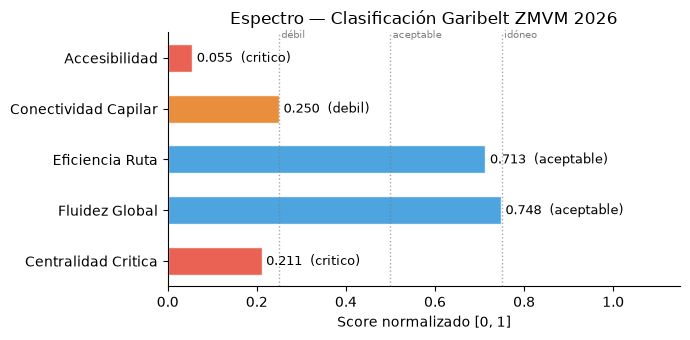

In [33]:
# ============================================================
# §6 — Tabla MJG — Clasificación Garibelt ZMVM 2026
# ============================================================

BANDA_LABELS = {
    'critico':       '🔴 Crítico',
    'debil':         '🟠 Débil',
    'aceptable':     '🔵 Aceptable',
    'idoneo':        '🟢 Idóneo',
    'no_disponible': '⚪ No disponible',
}

tabla_mjg = pd.DataFrame([
    {
        'Dimensión':   d.dimension.replace('_', ' ').title(),
        'Indicador':   d.indicador_fuente,
        'Valor bruto': d.valor_bruto,
        'Normalizado': d.valor_normalizado,
        'Banda':       BANDA_LABELS.get(d.banda, d.banda),
        'Descripción': d.metrica_descripcion,
    }
    for d in result.dimensions
])

BAND_CSS_MJG = {
    '🔴 Crítico':       f'background-color: {GARIBELT_COLORS["critico"]};   color: white; font-weight: bold',
    '🟠 Débil':         f'background-color: {GARIBELT_COLORS["debil"]};     color: white; font-weight: bold',
    '🔵 Aceptable':     f'background-color: {GARIBELT_COLORS["aceptable"]}; color: white; font-weight: bold',
    '🟢 Idóneo':        f'background-color: {GARIBELT_COLORS["idoneo"]};    color: white; font-weight: bold',
    '⚪ No disponible': 'background-color: #95a5a6; color: white; font-style: italic',
}

def _color_mjg(val):
    return BAND_CSS_MJG.get(val, '')

display(
    tabla_mjg.style
        .map(_color_mjg, subset=['Banda'])
        .format({'Normalizado': '{:.3f}', 'Valor bruto': '{:.4f}'})
        .set_caption('Tabla MJG — Clasificación Garibelt · ZMVM 2026 · Red de Transporte Público Masivo')
        .hide(axis='index')
        .set_properties(**{'text-align': 'left'})
)

# Gráfica de barras horizontales — espectro de la red
fig, ax = plt.subplots(figsize=(7, 3.5))
dims     = [d.dimension.replace('_', ' ').title() for d in result.dimensions]
scores   = [d.valor_normalizado for d in result.dimensions]
bandas   = [d.banda for d in result.dimensions]
colores  = [GARIBELT_COLORS.get(b, '#95a5a6') for b in bandas]

bars = ax.barh(dims, scores, color=colores, alpha=0.88, edgecolor='white', height=0.55)
for bar, score, banda in zip(bars, scores, bandas):
    ax.text(score + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}  ({banda})', va='center', fontsize=9)

# Líneas de umbral Escala Garibelt
for x, label in [(0.25, 'débil'), (0.50, 'aceptable'), (0.75, 'idóneo')]:
    ax.axvline(x, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    ax.text(x + 0.005, -0.55, label, fontsize=7, color='gray', va='top')

ax.set_xlabel('Score normalizado [0, 1]')
ax.set_title('Espectro — Clasificación Garibelt ZMVM 2026')
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## §7  Indicadores pendientes de incorporar

| Indicador | Símbolo | Estado | Issue | Bloqueado por |
|-----------|---------|--------|-------|---------------|
| Penalización Transferencia | $W_{s,h}$ | Parcial | — | Implementación incompleta (v2) |
| Robustez Geométrica | $\Delta E$ | No implementado | #5 | Fase 4 pendiente |
| Node Score Tipo B | VFT_score | No implementado | #12 | MV1 + MV2 de apimetro |

### Hoja de ruta Clasificación Garibelt v2

1. **v2** — Incorporar $W_{s,h}$ cuando la implementación esté completa. Nueva dimensión `penalizacion_transferencia`.
2. **v3** — Incorporar $\Delta E$ (Robustez). Cambio estructural: $\Delta E$ requiere múltiples ejecuciones del grafo con nodos removidos.
3. **v4** — Node Score con $\hat{a}_i$ (afluencia) y $\hat{p}_i$ (población captada 800 m). Requiere MV1 y MV2 de apimetro.

### Conectividad Tableau / QGIS

Los endpoints del servidor VFTModel exponen la Clasificación Garibelt para consumo en Tableau y QGIS:

```
GET /api/v1/network/topological/network-profile      →  perfil escalar (5 dimensiones)
GET /api/v1/network/geolayers/profile?layer=perfil_nodos  →  FeatureCollection por nodo
```

La integración visual se gestiona desde `Transport-gis-zmvm-mjg` — agregar proxy `/vftmodel/profile.geojson` en `tableau/geo_proxy/main.py`.